In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.grid'] = True

# Load the preprocessed dataset
df = pd.read_csv('spotify_emeritus.csv')

# Remove unnecessary columns and handle missing values
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df = df.dropna()


In [3]:
# Create composite features
print("Creating composite features...")

# Energy-loudness composite
df['energy_loudness_composite'] = (
    df['energy'] * df['loudness'].clip(lower=0)  # Clip negative values
).fillna(0)

# Energy-acousticness ratio
df['energy_acousticness_ratio'] = (
    df['energy'] / (df['acousticness'] + 0.01)  # Add small constant to avoid division by zero
)

# Genre encoding
print("\nEncoding genres...")
genre_popularity_mean = df.groupby('track_genre')['popularity'].mean()
df['genre_popularity_encoding'] = df['track_genre'].map(genre_popularity_mean)

# Create interaction features
print("\nCreating interaction features...")
df['danceability_energy'] = df['danceability'] * df['energy']
df['valence_energy'] = df['valence'] * df['energy']
df['loudness_danceability'] = df['loudness'] * df['danceability']

# Duration transformation
print("\nTransforming duration...")
df['duration_minutes'] = df['duration_ms'] / 60000
df['duration_minutes_log'] = np.log1p(df['duration_minutes'])

# Display summary of new features
print("\nNew features summary:")
new_features = ['energy_loudness_composite', 'energy_acousticness_ratio', 
                'genre_popularity_encoding', 'danceability_energy', 
                'valence_energy', 'loudness_danceability', 
                'duration_minutes', 'duration_minutes_log']

print(df[new_features].describe().round(3))


Creating composite features...

Encoding genres...

Creating interaction features...

Transforming duration...

New features summary:
       energy_loudness_composite  energy_acousticness_ratio  \
count                 113999.000                 113999.000   
mean                       0.001                     20.174   
std                        0.026                     29.603   
min                        0.000                      0.000   
25%                        0.000                      0.898   
50%                        0.000                      3.784   
75%                        0.000                     28.146   
max                        4.527                     99.868   

       genre_popularity_encoding  danceability_energy  valence_energy  \
count                 113999.000           113999.000      113999.000   
mean                      33.239                0.369           0.321   
std                       11.246                0.178           0.224   
min   

Correlations with Popularity:
popularity                   1.000000
genre_popularity_encoding    0.504196
duration_minutes_log         0.019037
loudness_danceability        0.014441
danceability_energy          0.006054
energy_loudness_composite   -0.000979
duration_minutes            -0.007129
valence_energy              -0.029292
energy_acousticness_ratio   -0.047912
Name: popularity, dtype: float64


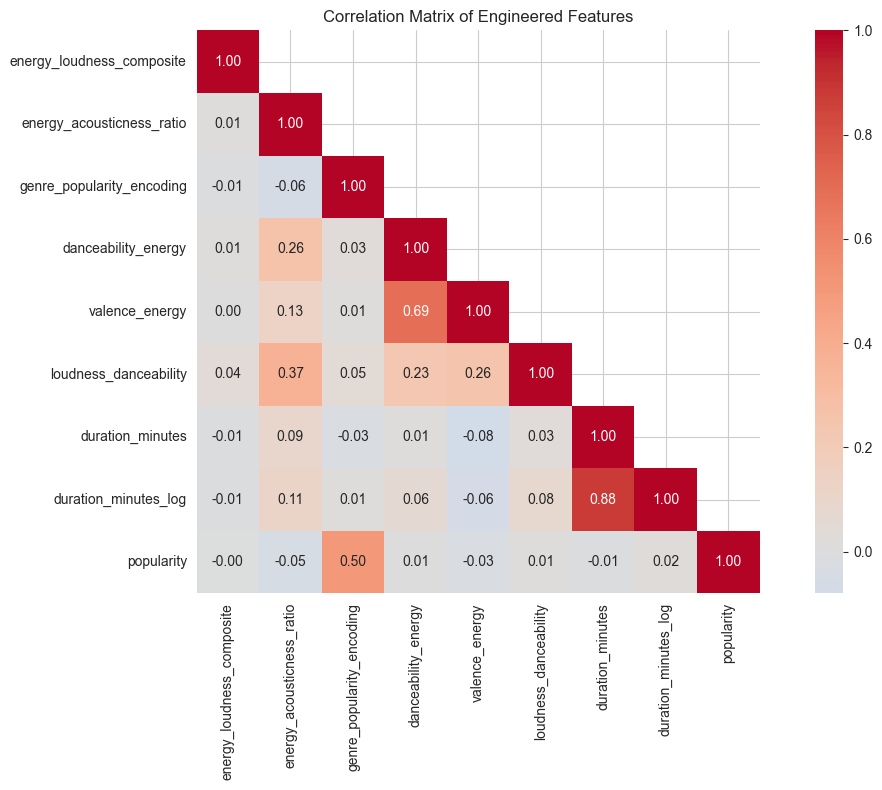

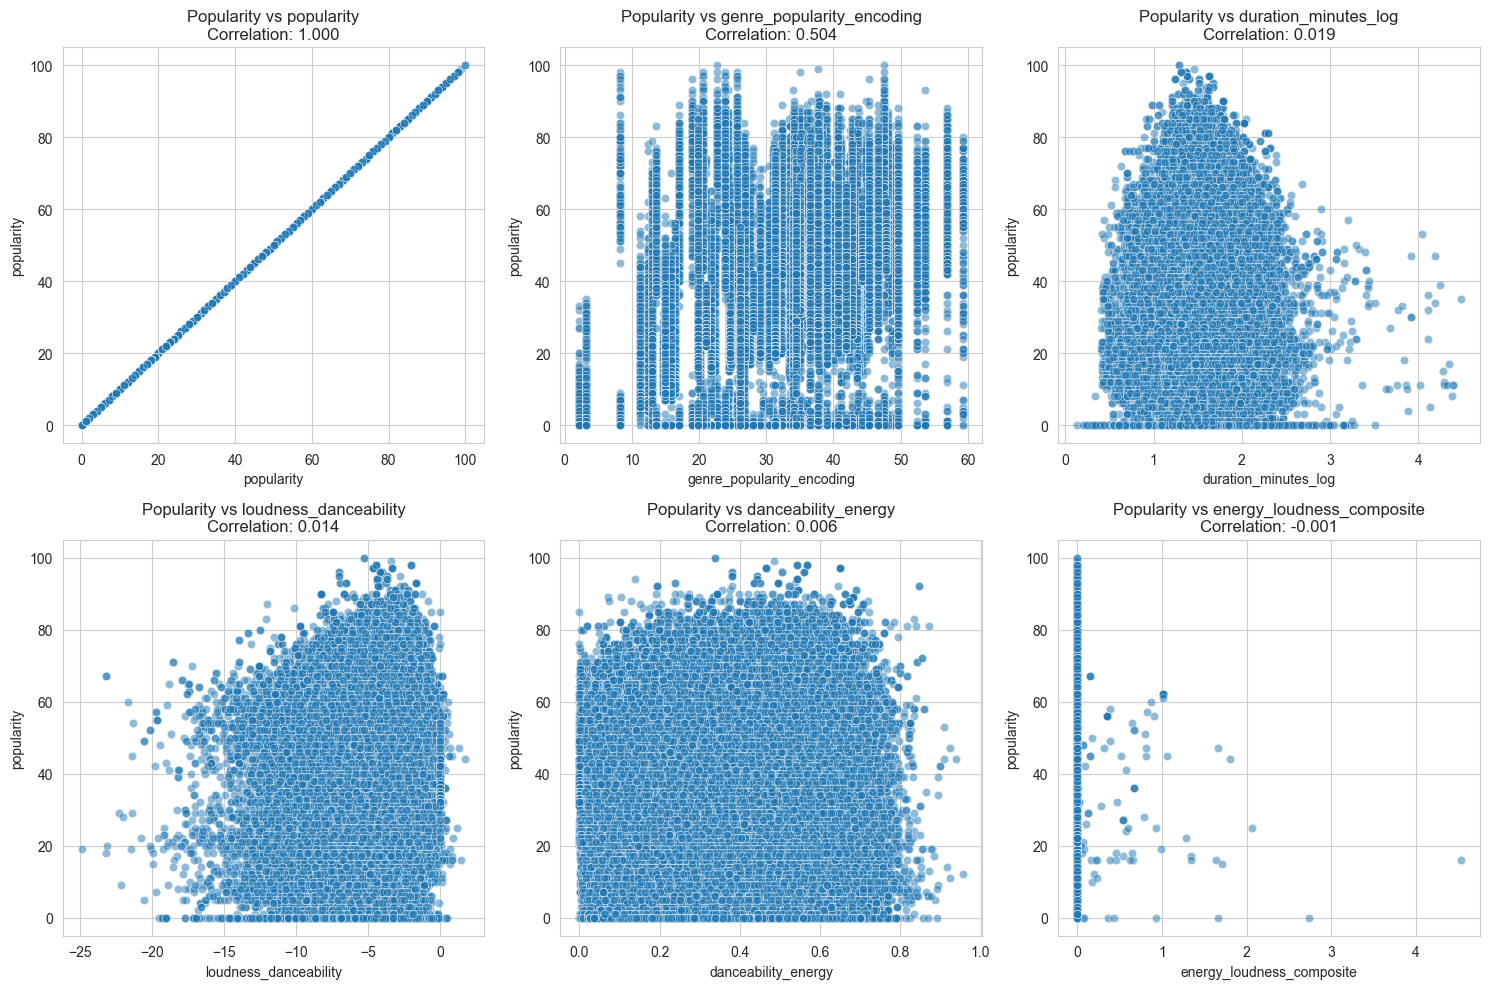

In [4]:
# Analyze correlations with popularity
correlations = df[new_features + ['popularity']].corr()['popularity'].sort_values(ascending=False)
print("Correlations with Popularity:")
print(correlations)

# Create correlation heatmap for engineered features
plt.figure(figsize=(12, 8))
correlation_matrix = df[new_features + ['popularity']].corr()
mask = np.triu(np.ones_like(correlation_matrix), k=1)
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Correlation Matrix of Engineered Features')
plt.tight_layout()
plt.show()

# Scatter plots for top correlated features
plt.figure(figsize=(15, 10))
top_features = correlations.index[:6]  # Get top 6 correlated features

for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df, x=feature, y='popularity', alpha=0.5)
    plt.title(f'Popularity vs {feature}\nCorrelation: {correlations[feature]:.3f}')
    
plt.tight_layout()
plt.show()
